# Step height


## Setup and configuration

In [1]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 6),
    "axes.grid": True,
})

COLUMNS = [
    "Freq_Hz",
    "Time_s",
    "Eps_real",
    "Eps_imag",
    "Temp_K",
    "MTime_s",
    "Phi_deg",
    "Z_real_Ohm",
    "Z_imag_Ohm",
    "TanPhi",
]

TIME_COL = "Time_Relative_s"
INTERPOLATED_VALUE_COLS = ("Eps_real",)

MATERIAL = "PEI5mgmL"
TEMPERATURE = "50°C"
MODE = "Abs"
PLOT_TIME_S = 4000
SELECTED_FILE = f"{MATERIAL}_{TEMPERATURE}_{MODE}.TXT"

# Atmosphere switch points are maintained centrally in Code/switch_points.py.


def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "data" / "Daten final").exists():
            return path
    raise FileNotFoundError("Could not find the project root with data/Daten final.")




def add_code_dir_to_path(project_root):
    code_dir = project_root / "Code"
    code_dir_text = str(code_dir)
    if code_dir_text not in sys.path:
        sys.path.insert(0, code_dir_text)


PROJECT_ROOT = find_project_root()
add_code_dir_to_path(PROJECT_ROOT)
import switch_points
importlib.reload(switch_points)
manual_switch_points = switch_points.MANUAL_SWITCH_POINTS

DATA_DIR = PROJECT_ROOT / "data" / "Daten final"
DATA_DIR / SELECTED_FILE

WindowsPath('c:/Users/Max/Documents/bachelor thesis/data/Daten final/PEI5mgmL_50°C_Abs.TXT')

## Load helpers


In [2]:
def load_measurements(data_dir=DATA_DIR, selected_file=None, material_filter="PEI5mgmL"):
    if selected_file is None:
        file_paths = sorted(data_dir.glob("*.TXT")) + sorted(data_dir.glob("*.txt"))
    else:
        file_path = data_dir / selected_file
        if not file_path.exists():
            raise FileNotFoundError(f"File not found: {file_path}")
        file_paths = [file_path]

    if selected_file is None and material_filter is not None:
        file_paths = [
            path for path in file_paths
            if path.stem.split("_")[0] == material_filter
        ]

    if not file_paths:
        raise FileNotFoundError(f"No .TXT files found in: {data_dir}")

    frames = []
    for path in file_paths:
        df = pd.read_csv(
            path,
            sep=r"\s+",
            skiprows=4,
            names=COLUMNS,
            encoding="latin1",
            engine="python",
        )

        parts = path.stem.split("_")
        if len(parts) >= 3:
            material, temperature, mode = parts[:3]
        else:
            material, temperature, mode = path.stem, None, None

        first_freq = df["Freq_Hz"].iloc[0]
        df["Spectrum_ID"] = (df["Freq_Hz"] == first_freq).cumsum() - 1
        df["Spectrum_Number"] = df["Spectrum_ID"] + 1
        df["Point_Number"] = range(1, len(df) + 1)
        df["Material"] = material
        df["Temperature"] = temperature
        df["Mode"] = mode
        df["Source_File"] = path.name

        frames.append(df)

    return pd.concat(frames, ignore_index=True)


def add_relative_switch_time(df, switch_points):
    df = df.copy()
    switch_time_rows = []

    for dataset_key, dataset in df.groupby(["Material", "Temperature", "Mode"], dropna=False):
        switch_point_number = switch_points.get(dataset_key)
        if switch_point_number is None:
            raise ValueError(
                "Missing Switch_Point_Number for series: "
                f"Material={dataset_key[0]}, Temperature={dataset_key[1]}, Mode={dataset_key[2]}"
            )

        switch_point = dataset[dataset["Point_Number"] == switch_point_number]
        next_point = dataset[dataset["Point_Number"] == switch_point_number + 1]

        if switch_point.empty or next_point.empty:
            raise ValueError(
                "The atmosphere switch must lie between two existing measurement points: "
                f"Material={dataset_key[0]}, Temperature={dataset_key[1]}, Mode={dataset_key[2]}, "
                f"Switch_Point_Number={switch_point_number}"
            )

        switch_time = float((switch_point["MTime_s"].iloc[0] + next_point["MTime_s"].iloc[0]) / 2)
        switch_spectrum_id = int(switch_point["Spectrum_ID"].iloc[0])

        switch_time_rows.append({
            "Material": dataset_key[0],
            "Temperature": dataset_key[1],
            "Mode": dataset_key[2],
            "Switch_Point_Number": int(switch_point_number),
            "Switch_Spectrum_ID": switch_spectrum_id,
            "Switch_Time_s": switch_time,
        })

    switch_times = pd.DataFrame(switch_time_rows)
    df = df.merge(switch_times, on=["Material", "Temperature", "Mode"], how="left")
    df["Time_Relative_s"] = df["MTime_s"] - df["Switch_Time_s"]
    return df, switch_times

## Interpolation helpers


In [3]:
def _linear_at(target_time, times, values):
    if len(times) < 2:
        return np.nan

    x0, x1 = float(times[0]), float(times[1])
    y0, y1 = float(values[0]), float(values[1])

    if x0 == x1:
        return np.nan

    return y0 + (target_time - x0) * (y1 - y0) / (x1 - x0)


def _insert_switch_support_point(freq_data, value_col, time_col=TIME_COL, target_time=0):
    before = freq_data[freq_data[time_col] < target_time].tail(2)
    if len(before) < 2:
        return freq_data[[time_col, value_col]].dropna().sort_values(time_col)

    switch_value = _linear_at(
        target_time,
        before[time_col].to_numpy(),
        before[value_col].to_numpy(),
    )

    support_points = freq_data[[time_col, value_col]].dropna().copy()
    support_points = support_points[~np.isclose(support_points[time_col], target_time)]
    support_points = pd.concat(
        [
            support_points,
            pd.DataFrame({time_col: [float(target_time)], value_col: [switch_value]}),
        ],
        ignore_index=True,
    )
    support_points = support_points.sort_values(time_col)
    return support_points.groupby(time_col, as_index=False)[value_col].mean()


def interpolate_complete_spectra(
    df,
    time_col=TIME_COL,
    freq_col="Freq_Hz",
    value_cols=INTERPOLATED_VALUE_COLS,
    dataset_cols=("Source_File", "Material", "Temperature", "Mode"),
    drop_incomplete=True,
    include_switch_time=True,
):
    rows = []
    metadata_cols = ["Switch_Point_Number", "Switch_Spectrum_ID", "Switch_Time_s"]

    for dataset_key, dataset in df.groupby(list(dataset_cols), dropna=False):
        dataset_key = dataset_key if isinstance(dataset_key, tuple) else (dataset_key,)
        dataset_meta = dict(zip(dataset_cols, dataset_key))

        target_times = np.sort(dataset[time_col].dropna().unique())
        if include_switch_time and not np.isclose(target_times, 0).any():
            target_times = np.sort(np.append(target_times, 0.0))

        frequencies = np.sort(dataset[freq_col].dropna().unique())
        dataset_metadata = {
            col: dataset[col].dropna().iloc[0]
            for col in metadata_cols
            if col in dataset.columns and not dataset[col].dropna().empty
        }

        interpolated_by_freq = {}
        for freq in frequencies:
            needed_cols = [time_col, freq_col, "Spectrum_ID", *metadata_cols, *value_cols]
            freq_data = (
                dataset.loc[dataset[freq_col] == freq, [col for col in needed_cols if col in dataset.columns]]
                .dropna(subset=[time_col])
                .sort_values(time_col)
            )

            grouped_values = {value_col: "mean" for value_col in value_cols}
            grouped_values.update({"Spectrum_ID": "first"})
            for col in metadata_cols:
                if col in freq_data.columns:
                    grouped_values[col] = "first"
            freq_data = freq_data.groupby(time_col, as_index=False).agg(grouped_values)

            interpolated_values = {}
            for value_col in value_cols:
                support_points = _insert_switch_support_point(
                    freq_data,
                    value_col,
                    time_col=time_col,
                    target_time=0,
                )
                support_times = support_points[time_col].to_numpy()
                support_values = support_points[value_col].to_numpy()

                interpolated_values[value_col] = np.interp(
                    target_times,
                    support_times,
                    support_values,
                    left=np.nan,
                    right=np.nan,
                )

            interpolated_by_freq[freq] = interpolated_values

        for spectrum_id, target_time in enumerate(target_times):
            for freq in frequencies:
                row = {
                    **dataset_meta,
                    **dataset_metadata,
                    "Interpolated_Spectrum_ID": spectrum_id,
                    time_col: target_time,
                    freq_col: freq,
                    "Is_Switch_Spectrum": bool(np.isclose(target_time, 0)),
                }
                for value_col in value_cols:
                    row[value_col] = interpolated_by_freq[freq][value_col][spectrum_id]
                rows.append(row)

    interpolated = pd.DataFrame(rows)

    if drop_incomplete:
        complete_ids = [*dataset_cols, "Interpolated_Spectrum_ID"]
        complete_mask = interpolated.groupby(complete_ids, dropna=False)[list(value_cols)].transform(
            lambda values: values.notna().all()
        )
        interpolated = interpolated[complete_mask.all(axis=1)].reset_index(drop=True)

    return interpolated

## Step height over time

In [4]:
def calculate_eps_real_step_height(
    df,
    value_col="Eps_real",
    freq_col="Freq_Hz",
    time_col=TIME_COL,
    spectrum_col="Interpolated_Spectrum_ID",
    dataset_cols=("Source_File", "Material", "Temperature", "Mode"),
    ignored_last_points=3,
):
    rows = []
    group_cols = [*dataset_cols, spectrum_col, time_col]

    for group_key, spectrum in df.groupby(group_cols, dropna=False):
        spectrum = spectrum.sort_values(freq_col).reset_index(drop=True)
        if len(spectrum) <= ignored_last_points:
            continue

        first = spectrum.iloc[0]
        comparison = spectrum.iloc[-(ignored_last_points + 1)]
        group_key = group_key if isinstance(group_key, tuple) else (group_key,)
        meta = dict(zip(group_cols, group_key))

        rows.append({
            **meta,
            "First_Freq_Hz": first[freq_col],
            "Comparison_Freq_Hz": comparison[freq_col],
            "First_Eps_real": first[value_col],
            "Comparison_Eps_real": comparison[value_col],
            "Eps_real_Step_Height": first[value_col] - comparison[value_col],
        })

    return pd.DataFrame(rows).sort_values([*dataset_cols, time_col]).reset_index(drop=True)


def as_selection_list(selection):
    if selection is None:
        return None
    if isinstance(selection, str):
        return [selection]
    return list(selection)

In [5]:
df_all_series = load_measurements(selected_file=None)
df_all_series, switch_times_all_series = add_relative_switch_time(df_all_series, manual_switch_points)
df_interpolated_all_series = interpolate_complete_spectra(df_all_series)
df_eps_real_step_height = calculate_eps_real_step_height(df_interpolated_all_series)

print(f"Step-height rows: {len(df_eps_real_step_height):,}")
df_eps_real_step_height.head()

Step-height rows: 37,795


,Source_File,Material,Temperature,Mode,Interpolated_Spectrum_ID,Time_Relative_s,First_Freq_Hz,Comparison_Freq_Hz,First_Eps_real,Comparison_Eps_real,Eps_real_Step_Height
0,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,23,-336.69,100.0,332530.0,6.215631,3.567176,2.648455
1,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,24,-332.76,100.0,332530.0,6.215600,3.567171,2.648429
2,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,25,-330.30,100.0,332530.0,6.215606,3.567168,2.648439
3,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,26,-327.86,100.0,332530.0,6.215613,3.567164,2.648448
4,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,27,-325.19,100.0,332530.0,6.215619,3.567161,2.648458


## Plot helpers


In [6]:
def plot_step_height(
    df,
    materials=("PEI5mgmL",),
    temperatures=None,
    modes=("Abs", "Des"),
):
    plot_df = df.copy()
    selection_filters = {
        "Material": as_selection_list(materials),
        "Temperature": as_selection_list(temperatures),
        "Mode": as_selection_list(modes),
    }

    for column, allowed_values in selection_filters.items():
        if allowed_values is not None:
            plot_df = plot_df[plot_df[column].isin(allowed_values)]

    if plot_df.empty:
        available = df[["Material", "Temperature", "Mode"]].drop_duplicates()
        raise ValueError(
            "No step-height data found for this selection. Available series:\n"
            + available.to_string(index=False)
        )

    fig, ax = plt.subplots(figsize=(11, 7))
    for keys, series in plot_df.groupby(["Material", "Temperature", "Mode"], dropna=False):
        material, temperature, mode = keys
        series = series.sort_values(TIME_COL)
        ax.plot(
            series[TIME_COL],
            series["Eps_real_Step_Height"],
            marker="o",
            markersize=2.5,
            linewidth=1,
            label=f"{material} {temperature} {mode}",
        )

    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.8)
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xlabel("Time relative to atmosphere switch (s, symlog scale)")
    ax.set_ylabel("Eps real step height")
    ax.set_title("Step height over time from interpolated spectra")
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## Example plot


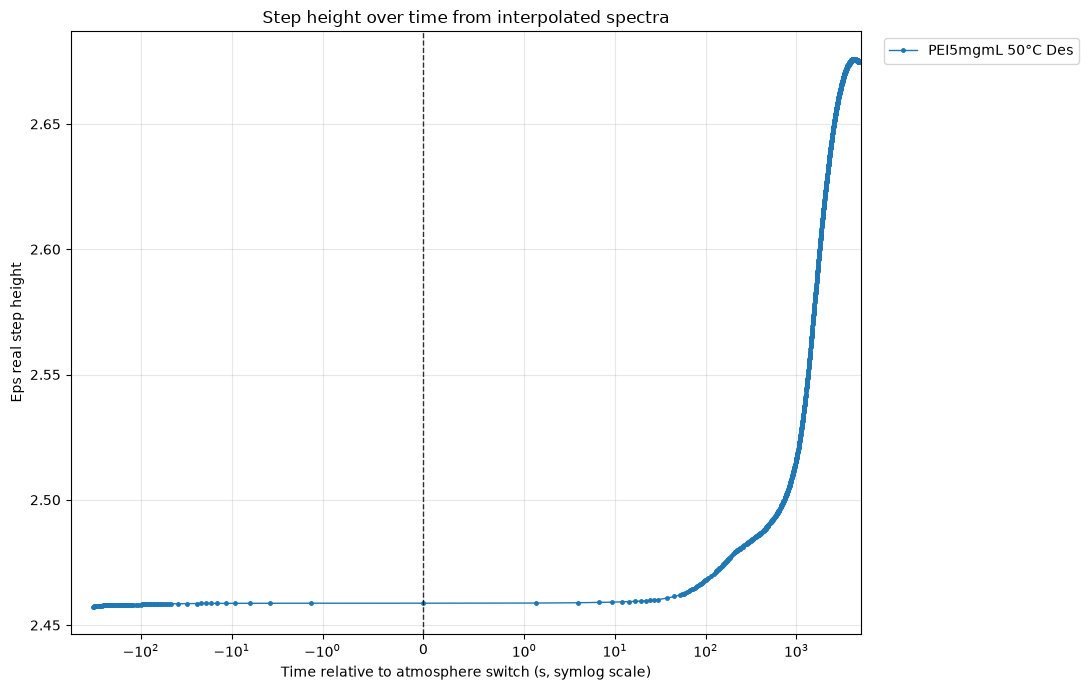

In [10]:
plot_step_height(
    df_eps_real_step_height,
    materials=("PEI5mgmL",),
    temperatures=("50°C"),
    modes=( "Des"),
)

## Influence of the atmosphere-switch point


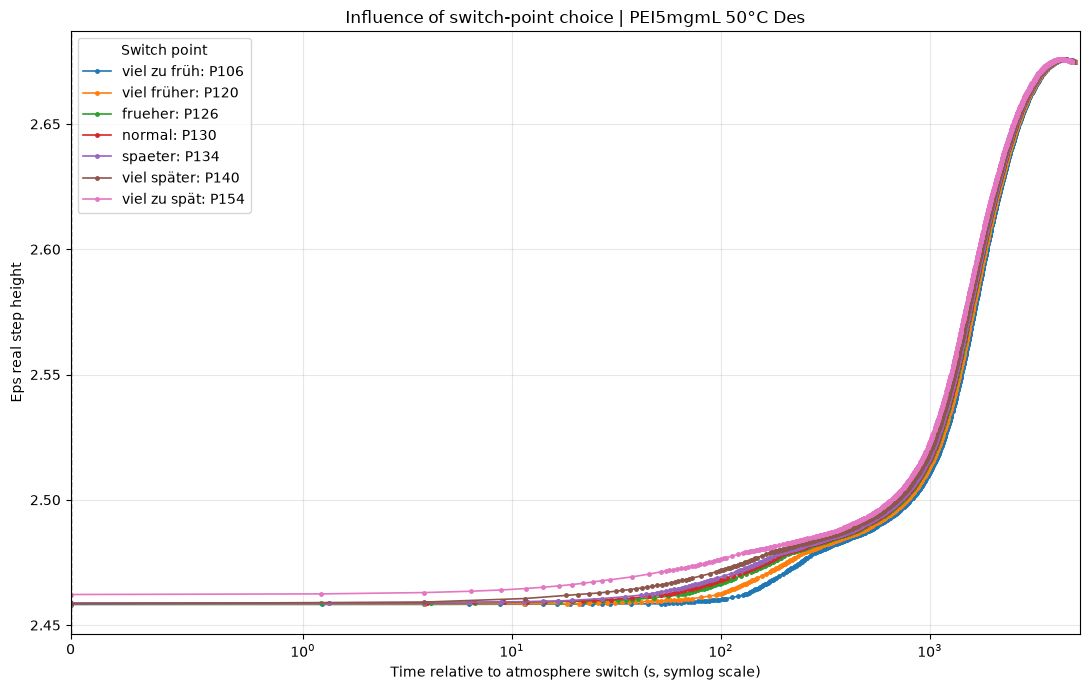

In [20]:
variant_material = "PEI5mgmL"
variant_temperature = "50" + chr(176) + "C"
variant_mode = "Des"
variant_key = (variant_material, variant_temperature, variant_mode)
switch_point_variants = {
    "viel zu früh: P106": 106,
    "viel früher: P120": 118,
    "frueher: P126": 126,
    "normal: P130": 130,
    "spaeter: P134": 134,
    "viel später: P140": 142,
    "viel zu spät: P154": 154,
}

variant_frames = []
for label, switch_point_number in switch_point_variants.items():
    variant_switch_points = dict(manual_switch_points)
    variant_switch_points[variant_key] = switch_point_number

    variant_raw = load_measurements(selected_file=None)
    variant_raw = variant_raw[
        (variant_raw["Material"] == variant_material)
        & (variant_raw["Temperature"] == variant_temperature)
        & (variant_raw["Mode"] == variant_mode)
    ].copy()
    if variant_raw.empty:
        raise ValueError(f"No data found for {variant_key}.")

    variant_raw, _ = add_relative_switch_time(variant_raw, variant_switch_points)
    variant_interpolated = interpolate_complete_spectra(variant_raw)
    variant_step_height = calculate_eps_real_step_height(variant_interpolated)
    variant_step_height["Switch_Point_Variant"] = label
    variant_step_height["Switch_Point_Number"] = switch_point_number
    variant_frames.append(variant_step_height)

switch_point_sensitivity = pd.concat(variant_frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 7))
for label, series in switch_point_sensitivity.groupby("Switch_Point_Variant", sort=False):
    series = series.sort_values(TIME_COL)
    ax.plot(
        series[TIME_COL],
        series["Eps_real_Step_Height"],
        marker="o",
        markersize=2.5,
        linewidth=1.2,
        label=label,
    )

ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.8)
ax.set_xscale("symlog", linthresh=1)
ax.set_xlabel("Time relative to atmosphere switch (s, symlog scale)")
ax.set_ylabel("Eps real step height")
ax.set_title(f"Influence of switch-point choice | {variant_material} {variant_temperature} {variant_mode}")
ax.grid(True, which="both", alpha=0.3)
ax.legend(title="Switch point")
plt.tight_layout()
plt.xlim(0, None)
#plt.ylim(2.45, 2.5)
plt.show()
